<a href="https://colab.research.google.com/github/zeynep-serra/ML_Notes/blob/main/R/R_DimensionalityReduction_PCA_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


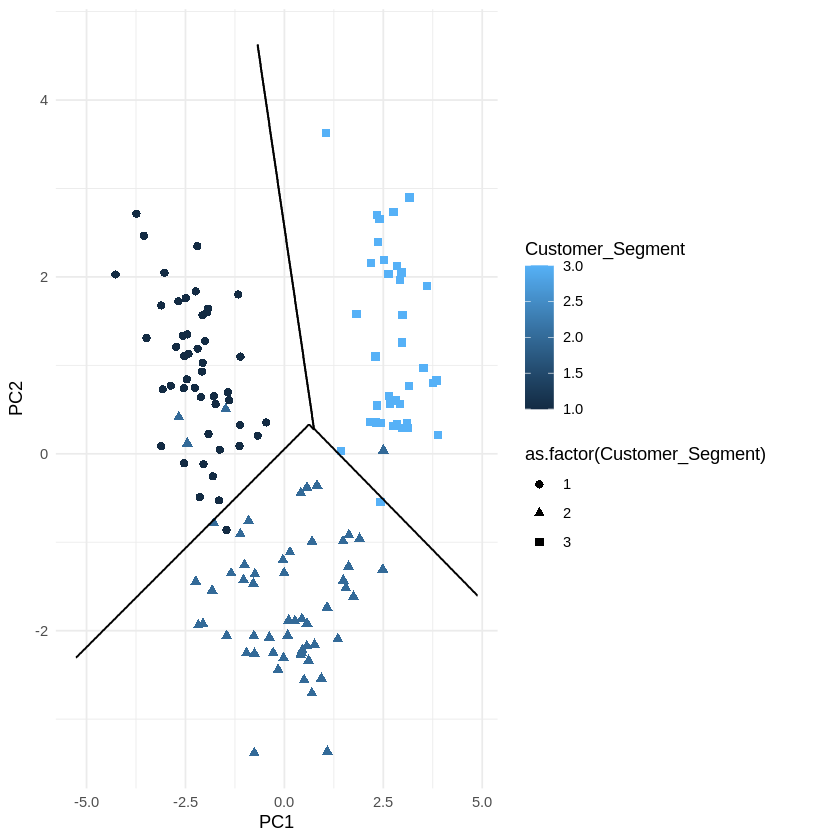

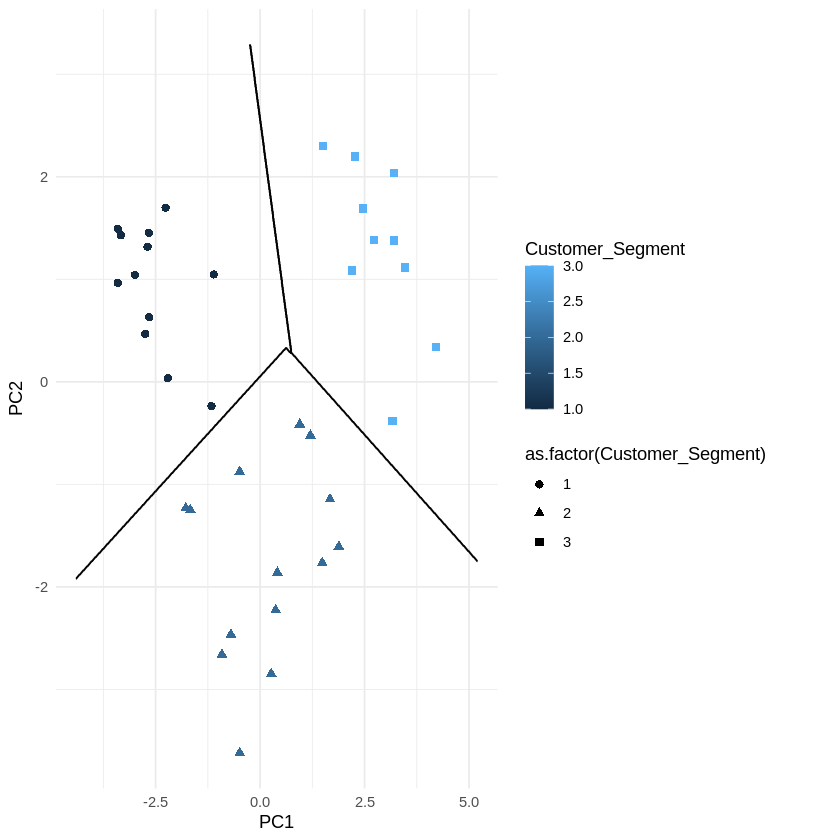

In [ ]:
data = read.csv("wine.csv")

library(caTools)
library(caret)
library(e1071)
library(ggplot2)

split = sample.split(data$Customer_Segment, SplitRatio = 0.8)
train = subset(data, split == TRUE)
test = subset(data, split == FALSE)

train[-14] = scale(train[-14])
test[-14] = scale(test[-14])

# pca
pca = preProcess(x = train[-14], method="pca", pcaComp=2)
train = predict(pca, train)
train = train[c(2, 3, 1)]
test = predict(pca, test)
test = test[c(2, 3, 1)]

classifier = svm(formula=Customer_Segment ~ .,
                   data = train,
                   type="C-classification",
                   kernel="linear")

y_pred = predict(classifier, test[-3])

# Visualising the Training set results
set = train
X1 = seq(min(set[, 1]) - 1, max(set[, 1]) + 1, by = 0.01)
X2 = seq(min(set[, 2]) - 1, max(set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('PC1', 'PC2')
y_grid = predict(classifier, newdata = grid_set)
ggplot(set, aes(x = PC1, y = PC2, colour = Customer_Segment)) +
  geom_point(aes(shape = as.factor(Customer_Segment)), size = 2) +
  geom_contour(data = data.frame(grid_set, Customer_Segment = y_grid), aes(x = PC1, y = PC2, z = as.numeric(Customer_Segment)), breaks = unique(as.numeric(y_grid)), colour = 'black', size = 0.5) +
  theme_minimal()


# Visualising the Test set results
set = test
X1 = seq(min(set[, 1]) - 1, max(set[, 1]) + 1, by = 0.01)
X2 = seq(min(set[, 2]) - 1, max(set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('PC1', 'PC2')
y_grid = predict(classifier, newdata = grid_set)
ggplot(set, aes(x = PC1, y = PC2, colour = Customer_Segment)) +
  geom_point(aes(shape = as.factor(Customer_Segment)), size = 2) +
  geom_contour(data = data.frame(grid_set, Customer_Segment = y_grid), aes(x = PC1, y = PC2, z = as.numeric(Customer_Segment)), breaks = unique(as.numeric(y_grid)), colour = 'black', size = 0.5) +
  theme_minimal()

In [ ]:
data = read.csv("wine.csv")

split = sample.split(data$Customer_Segment, SplitRatio = 0.8)
train = subset(data, split == TRUE)
test = subset(data, split == FALSE)

train[-14] = scale(train[-14])
test[-14] = scale(test[-14])

# lda
library(MASS)

lda = lda(formula=Customer_Segment ~ ., data=train)
train = as.data.frame(predict(lda, train))
train = train[c(5, 6, 1)]
test = as.data.frame(predict(lda, test))
test = test[c(5, 6, 1)]

classifier = svm(formula=class ~ .,
                   data = train,
                   type="C-classification",
                   kernel="linear")

y_pred = predict(classifier, test[-3])

cm = table(test[, 3], y_pred)
cm

   y_pred
     1  2  3
  1 12  0  0
  2  0 15  0
  3  0  0  9

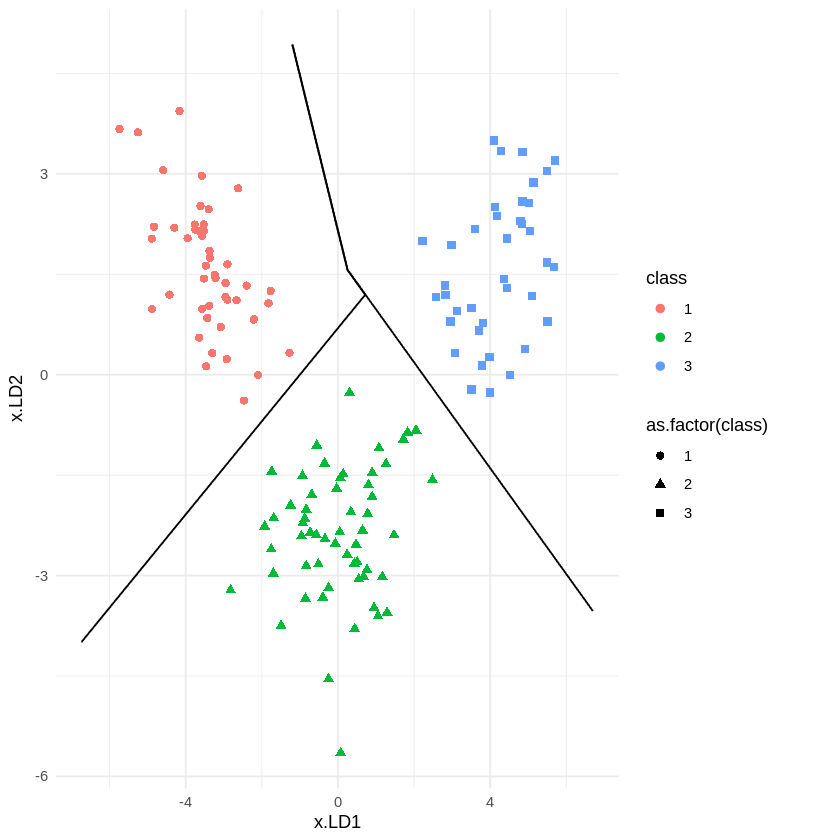

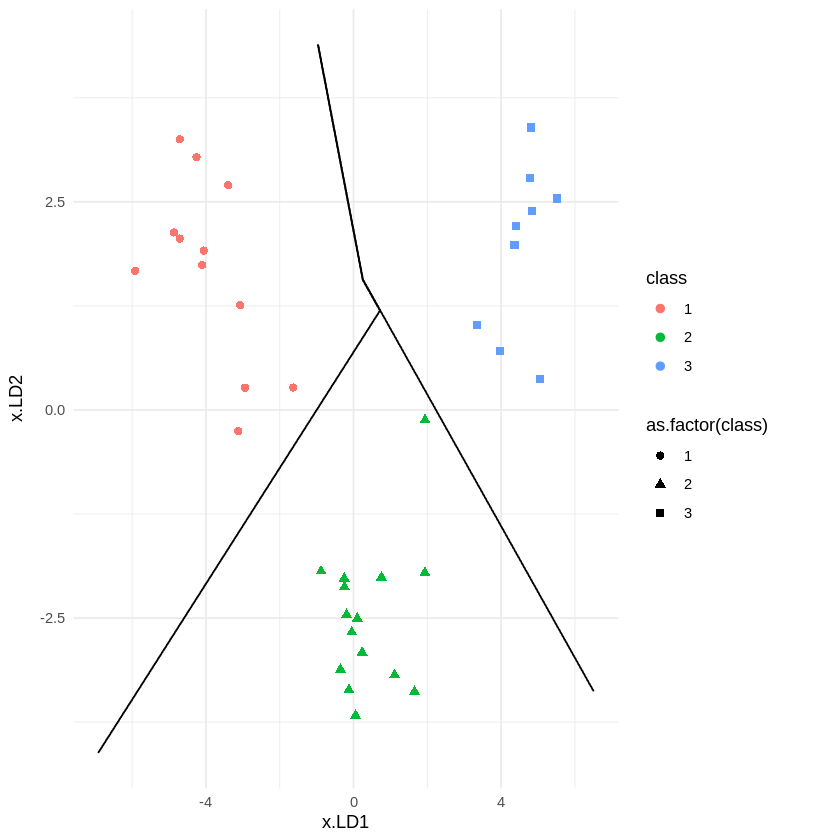

In [ ]:
# Visualising the Training set results
set = train
X1 = seq(min(set[, 1]) - 1, max(set[, 1]) + 1, by = 0.01)
X2 = seq(min(set[, 2]) - 1, max(set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('x.LD1', 'x.LD2')
y_grid = predict(classifier, newdata = grid_set)
ggplot(set, aes(x = x.LD1, y = x.LD2, colour = class)) +
  geom_point(aes(shape = as.factor(class)), size = 2) +
  geom_contour(data = data.frame(grid_set, class = y_grid), aes(x = x.LD1, y = x.LD2, z = as.numeric(class)), breaks = unique(as.numeric(y_grid)), colour = 'black', size = 0.5) +
  theme_minimal()

# Visualising the Test set results
set = test
X1 = seq(min(set[, 1]) - 1, max(set[, 1]) + 1, by = 0.01)
X2 = seq(min(set[, 2]) - 1, max(set[, 2]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)
colnames(grid_set) = c('x.LD1', 'x.LD2')
y_grid = predict(classifier, newdata = grid_set)
ggplot(set, aes(x = x.LD1, y = x.LD2, colour = class)) +
  geom_point(aes(shape = as.factor(class)), size = 2) +
  geom_contour(data = data.frame(grid_set, class = y_grid), aes(x = x.LD1, y = x.LD2, z = as.numeric(class)), breaks = unique(as.numeric(y_grid)), colour = 'black', size = 0.5) +
  theme_minimal()